<a href="https://colab.research.google.com/github/Steven10P/Analisis-KDM-PNC/blob/main/notebooks/02b_MNIST_PNC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# BLOQUE 1: MLOps, Drive, PNC y Entorno
# ==========================================
import os
import sys
import yaml
import torch
from google.colab import drive

# 1. CONEXIÓN A DRIVE Y GITHUB (Vía token seguro)
print("--- CONECTANDO A DRIVE Y CONFIGURANDO GITHUB ---")
drive.mount('/content/drive', force_remount=True)
CARPETA_DRIVE = '/content/drive/MyDrive/01.Maestria/MLOps'

# Aseguramos que el script de setup esté en el path
if CARPETA_DRIVE not in sys.path:
    sys.path.append(CARPETA_DRIVE)

import setup_env

# Esto lee el token y clona/actualiza el repo automáticamente
setup_env.init_project(drive_token_path=f"{CARPETA_DRIVE}/github_token.txt")

# Definimos las rutas del repo
REPO_PATH = "/content/Analisis-KDM-PNC"
if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

# 2. CLONAR E INYECTAR LIBRERÍA PNC (Pedro Zuidberg)
print("\n--- CLONANDO LIBRERÍA PNC ---")
%cd /content
if not os.path.exists('ProbabilisticNeuralCircuits'):
    !git clone https://github.com/pedrozudo/ProbabilisticNeuralCircuits.git

PNC_PATH = '/content/ProbabilisticNeuralCircuits'
if PNC_PATH not in sys.path:
    sys.path.append(PNC_PATH)



--- CONECTANDO A DRIVE Y CONFIGURANDO GITHUB ---
Mounted at /content/drive
🚀 Iniciando configuración del entorno MLOps...
[*] Clonando el repositorio Analisis-KDM-PNC...
[*] Directorio de trabajo establecido en: /content/Analisis-KDM-PNC
[*] Credenciales de Git configuradas.

[✅ ÉXITO] Entorno listo. Ya puedes importar módulos de Analisis-KDM-PNC.

--- CLONANDO LIBRERÍA PNC ---
/content
Cloning into 'ProbabilisticNeuralCircuits'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 38 (delta 11), reused 35 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 17.43 KiB | 1.94 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [2]:
# 3. VERIFICACIÓN DE HARDWARE (PyTorch)
print("\n--- VERIFICACIÓN DE ENTORNO ---")
print(f"PyTorch Version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de entrenamiento asignado: {device}")
if device.type != 'cuda':
    print("⚠️ ADVERTENCIA: No estás usando GPU. Actívala en el menú de Colab.")



--- VERIFICACIÓN DE ENTORNO ---
PyTorch Version: 2.10.0+cu128
Dispositivo de entrenamiento asignado: cuda


In [3]:
# 4. CARGAR PIPELINE DE DATOS (PyTorch)
print("\n--- PREPARANDO DATOS MNIST (Tensores) ---")
from src.data.dataset_loaders import PNCDataPipelineKFold

pipeline_pnc = PNCDataPipelineKFold(batch_size=128, data_dir=f'{REPO_PATH}/data')
print(f"[✅] Muestras para K-Fold (Train+Val): {len(pipeline_pnc.train_set_full)}")
print(f"[✅] Muestras para Test final: {len(pipeline_pnc.test_set_full)}")




--- PREPARANDO DATOS MNIST (Tensores) ---
[INFO] Descargando/Cargando datasets MNIST (Tensores PyTorch)...


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 536kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.83MB/s]

[✅] Muestras para K-Fold (Train+Val): 60000
[✅] Muestras para Test final: 10000


In [4]:
# 5. CARGAR CONFIGURACIÓN DESDE YAML
with open(f"{REPO_PATH}/configs/mnist/pnc.yaml", 'r') as file:
    config_pnc = yaml.safe_load(file)

print("\n[INFO] Parámetros base cargados:", config_pnc['fixed_params'])
print("[INFO] Espacio de búsqueda cargado:", config_pnc['grid_search'])


[INFO] Parámetros base cargados: {'height': 28, 'width': 28, 'n_classes': 10, 'mixing': 'sum', 'batch_size': 128}
[INFO] Espacio de búsqueda cargado: {'components': [5, 10, 15], 'lr': [0.01, 0.005], 'momentum': [0.9, 0.5]}


In [5]:
1

1

In [7]:
# ==========================================
# BLOQUE 2: ENTRENAMIENTO PNC Y TRAZABILIDAD
# ==========================================
import itertools
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
import yaml
import os
import sys
import importlib
import torch
import torch.nn as nn

# 2. Rutas de persistencia MLOps
ruta_base = os.path.join(REPO_PATH, "resultados/mnist")
os.makedirs(f"{ruta_base}/metricas", exist_ok=True)
os.makedirs(f"{ruta_base}/modelos", exist_ok=True)

ruta_historial_csv = f"{ruta_base}/metricas/pnc_kfold_gridsearch_history.csv"
ruta_mejor_modelo_pnc = f"{ruta_base}/modelos/mejor_pnc_mnist.pth"
ruta_mejores_params = f"{ruta_base}/metricas/best_pnc_params.yaml"

# 3. Lógica Fast-Track MLOps
if os.path.exists(ruta_mejores_params) and os.path.exists(ruta_mejor_modelo_pnc):
    print(f"[⏩] Búsqueda ya realizada. Mejor modelo en: {ruta_mejor_modelo_pnc}")
    print("Saltando el entrenamiento...")
else:
    print("\n--- INICIANDO ENTRENAMIENTO PNC (GRID SEARCH + K-FOLD) ---")

    # Extraer parámetros de configuración
    EPOCHS = 5 # Mantenemos 5 para exploración rápida (cámbialo a 20 si tienes tiempo en GPU)
    K_FOLDS = 3 # 3 Folds para validación cruzada
    kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

    params_grid = config_pnc['grid_search']
    keys, values = zip(*params_grid.items())
    grid_configs = [dict(zip(keys, v)) for v in itertools.product(*values)]
    print(f"Total arquitecturas PNC a evaluar: {len(grid_configs)}")

    historial_global_pnc = []
    mejor_accuracy_global_pnc = 0.0
    mejor_config_global_pnc = None

    for idx_config, conf in enumerate(grid_configs):
        conf_completa = {**config_pnc['fixed_params'], **conf}
        print(f"\n[{idx_config+1}/{len(grid_configs)}] Config: Components={conf['components']}, LR={conf['lr']}, Momentum={conf['momentum']}")

        # Para acortar tiempos de Grid Search en tesis, usamos un subconjunto del 33%
        # Si deseas usar todo el dataset, cambia 'idx_sample_global' por 'pipeline_pnc.train_set_full'
        TOTAL_MUESTRAS = len(pipeline_pnc.train_set_full)
        idx_sample_global = np.random.choice(TOTAL_MUESTRAS, int(TOTAL_MUESTRAS * 0.33), replace=False)

        for fold, (train_rel_idx, val_rel_idx) in enumerate(kf.split(idx_sample_global)):
            train_idx = idx_sample_global[train_rel_idx]
            val_idx = idx_sample_global[val_rel_idx]

            train_loader, val_loader = pipeline_pnc.get_fold_loaders(train_idx, val_idx)
            modelo_pnc, optimizer_pnc, criterion, total_params = build_pnc_model(conf_completa, device)

            for epoch in range(EPOCHS):
                epoch_time_start = time.time()

                # --- FASE DE ENTRENAMIENTO ---
                modelo_pnc.train()
                train_loss, train_correct, train_total = 0.0, 0, 0
                for data, target in train_loader:
                    # TRANSFORMACIÓN CRÍTICA PARA PNC (Binarización/Escalado)
                    data = data.squeeze(1).to(device)
                    data = (data * 255.0).long().float()
                    target = target.to(device)

                    optimizer_pnc.zero_grad()
                    log_probs = modelo_pnc(data)
                    loss = criterion(log_probs, target)
                    loss.backward()
                    optimizer_pnc.step()

                    train_loss += loss.item() * data.size(0)
                    _, predicted = log_probs.max(1)
                    train_total += target.size(0)
                    train_correct += predicted.eq(target).sum().item()

                # --- FASE DE VALIDACIÓN ---
                modelo_pnc.eval()
                val_loss, val_correct, val_total = 0.0, 0, 0
                with torch.no_grad():
                    for data, target in val_loader:
                        # MISMA TRANSFORMACIÓN PARA VALIDACIÓN
                        data = data.squeeze(1).to(device)
                        data = (data * 255.0).long().float()
                        target = target.to(device)

                        log_probs = modelo_pnc(data)
                        loss = criterion(log_probs, target)

                        val_loss += loss.item() * data.size(0)
                        _, predicted = log_probs.max(1)
                        val_total += target.size(0)
                        val_correct += predicted.eq(target).sum().item()

                # --- REGISTRO Y MLOps ---
                epoch_time = time.time() - epoch_time_start
                val_acc = val_correct / val_total

                registro_epoca = {
                    'config_id': idx_config + 1, 'components': conf['components'],
                    'lr': conf['lr'], 'fold': fold + 1, 'epoch': epoch + 1,
                    'train_loss': train_loss / train_total, 'train_acc': train_correct / train_total,
                    'val_loss': val_loss / val_total, 'val_acc': val_acc,
                    'epoch_time_seconds': epoch_time, 'total_params': total_params
                }
                historial_global_pnc.append(registro_epoca)

                # Si es el mejor modelo absoluto, guardamos sus pesos
                if val_acc > mejor_accuracy_global_pnc:
                    mejor_accuracy_global_pnc = val_acc
                    mejor_config_global_pnc = conf
                    torch.save(modelo_pnc.state_dict(), ruta_mejor_modelo_pnc)

            print(f"    Fin Fold {fold+1} | Val Acc: {val_acc:.4f} | Tiempo prom. época: ~{epoch_time:.1f}s")

    # Guardar métricas en CSV
    df_resultados = pd.DataFrame(historial_global_pnc)
    df_resultados.to_csv(ruta_historial_csv, index=False)

    # Guardar la mejor configuración en YAML
    with open(ruta_mejores_params, 'w') as file:
        yaml.dump(mejor_config_global_pnc, file)

    print(f"\n[🏆] Búsqueda finalizada. Mejor Val Acc: {mejor_accuracy_global_pnc:.4f}")
    print(f"[🏆] Mejor config: {mejor_config_global_pnc}")
    print(f"[✅] Modelo guardado en: {ruta_mejor_modelo_pnc}")
    print(f"[✅] Historial CSV guardado en: {ruta_historial_csv}")


--- INICIANDO ENTRENAMIENTO PNC (GRID SEARCH + K-FOLD) ---
Total arquitecturas PNC a evaluar: 12

[1/12] Config: Components=5, LR=0.01
    Fin Fold 1 | Val Acc: 0.8368 | Tiempo prom. época: ~6.0s
    Fin Fold 2 | Val Acc: 0.8482 | Tiempo prom. época: ~6.3s
    Fin Fold 3 | Val Acc: 0.8482 | Tiempo prom. época: ~7.5s

[2/12] Config: Components=5, LR=0.01
    Fin Fold 1 | Val Acc: 0.6629 | Tiempo prom. época: ~5.9s
    Fin Fold 2 | Val Acc: 0.6712 | Tiempo prom. época: ~5.9s
    Fin Fold 3 | Val Acc: 0.6430 | Tiempo prom. época: ~6.2s

[3/12] Config: Components=5, LR=0.005
    Fin Fold 1 | Val Acc: 0.7894 | Tiempo prom. época: ~6.4s
    Fin Fold 2 | Val Acc: 0.7877 | Tiempo prom. época: ~6.2s
    Fin Fold 3 | Val Acc: 0.7906 | Tiempo prom. época: ~5.9s

[4/12] Config: Components=5, LR=0.005
    Fin Fold 1 | Val Acc: 0.4718 | Tiempo prom. época: ~6.0s
    Fin Fold 2 | Val Acc: 0.5462 | Tiempo prom. época: ~6.4s
    Fin Fold 3 | Val Acc: 0.5036 | Tiempo prom. época: ~6.3s

[5/12] Config: 

In [8]:
1

1

In [13]:
# ==========================================
# BLOQUE 3: ENTRENAMIENTO FINAL Y CURVAS (PNC)
# ==========================================
import yaml
import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader
import os

# 1. Rutas de artefactos finales
ruta_mejores_params = f"{REPO_PATH}/resultados/mnist/metricas/best_pnc_params.yaml"
ruta_modelo_campeon = f"{REPO_PATH}/resultados/mnist/modelos/pnc_best_model.weights.pth"
ruta_matriz_conf = f"{REPO_PATH}/resultados/mnist/metricas/pnc_confusion_matrix.png"
ruta_reporte_test = f"{REPO_PATH}/resultados/mnist/metricas/pnc_test_report.csv"
ruta_curvas_entrenamiento = f"{REPO_PATH}/resultados/mnist/metricas/pnc_training_curves.png" # NUEVA RUTA

# 2. Cargar la configuración ganadora
if not os.path.exists(ruta_mejores_params):
    raise FileNotFoundError("¡No se encontró el archivo de mejores parámetros! Ejecuta el Bloque 2 primero.")

with open(ruta_mejores_params, 'r') as file:
    best_params = yaml.safe_load(file)

print("\n--- INICIANDO ENTRENAMIENTO DEL CAMPEÓN PNC ---")
print(f"Parámetros óptimos a utilizar: {best_params}")

conf_completa = {**config_pnc['fixed_params'], **best_params}

# 3. Preparar DataLoaders
train_loader_full = DataLoader(pipeline_pnc.train_set_full, batch_size=conf_completa['batch_size'], shuffle=True)
test_loader = pipeline_pnc.get_test_loader()

# 4. Instanciar el modelo definitivo
from src.models.pnc_factory import build_pnc_model
modelo_final, optimizer, criterion, total_params = build_pnc_model(conf_completa, device)

# 5. Bucle de Entrenamiento Final (con historial)
EPOCHS_FINAL = 50 # Subimos a 50 para máxima convergencia
print(f"Entrenando sobre {len(pipeline_pnc.train_set_full)} muestras por {EPOCHS_FINAL} épocas...")

# Listas para guardar la evolución
historial_train_loss, historial_train_acc = [], []
historial_test_loss, historial_test_acc = [], []

tiempo_inicio_total = time.time()
for epoch in range(EPOCHS_FINAL):
    epoch_time_start = time.time()

    # --- FASE DE TRAIN ---
    modelo_final.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for data, target in train_loader_full:
        data = data.squeeze(1).to(device)
        data = (data * 255.0).long().float()
        target = target.to(device)

        optimizer.zero_grad()
        log_probs = modelo_final(data)
        loss = criterion(log_probs, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * data.size(0)
        _, predicted = log_probs.max(1)
        train_total += target.size(0)
        train_correct += predicted.eq(target).sum().item()

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    historial_train_loss.append(epoch_train_loss)
    historial_train_acc.append(epoch_train_acc)

    # --- FASE DE EVALUACIÓN (TEST) POR ÉPOCA ---
    modelo_final.eval()
    test_loss, test_correct, test_total = 0.0, 0, 0
    with torch.no_grad():
        for data, target in test_loader:
            data = data.squeeze(1).to(device)
            data = (data * 255.0).long().float()
            target = target.to(device)

            log_probs = modelo_final(data)
            loss = criterion(log_probs, target)

            test_loss += loss.item() * data.size(0)
            _, predicted = log_probs.max(1)
            test_total += target.size(0)
            test_correct += predicted.eq(target).sum().item()

    epoch_test_loss = test_loss / test_total
    epoch_test_acc = test_correct / test_total
    historial_test_loss.append(epoch_test_loss)
    historial_test_acc.append(epoch_test_acc)

    epoch_time = time.time() - epoch_time_start
    print(f"  Época [{epoch+1:02d}/{EPOCHS_FINAL}] | Train Acc: {epoch_train_acc:.4f} - Val Acc: {epoch_test_acc:.4f} | Tiempo: {epoch_time:.1f}s")

tiempo_total_entrenamiento = time.time() - tiempo_inicio_total
print(f"\n[✅] Entrenamiento completado en {tiempo_total_entrenamiento/60:.1f} minutos.")

# 6. Guardar pesos del modelo campeón
torch.save(modelo_final.state_dict(), ruta_modelo_campeon)


--- INICIANDO ENTRENAMIENTO DEL CAMPEÓN PNC ---
Parámetros óptimos a utilizar: {'components': 5, 'lr': 0.01, 'momentum': 0.9}
Entrenando sobre 60000 muestras por 50 épocas...
  Época [01/50] | Train Acc: 0.7160 - Val Acc: 0.8520 | Tiempo: 23.6s
  Época [02/50] | Train Acc: 0.8556 - Val Acc: 0.8772 | Tiempo: 28.2s
  Época [03/50] | Train Acc: 0.8751 - Val Acc: 0.8875 | Tiempo: 23.2s
  Época [04/50] | Train Acc: 0.8840 - Val Acc: 0.8924 | Tiempo: 23.3s
  Época [05/50] | Train Acc: 0.8894 - Val Acc: 0.8970 | Tiempo: 23.6s
  Época [06/50] | Train Acc: 0.8940 - Val Acc: 0.9007 | Tiempo: 23.5s
  Época [07/50] | Train Acc: 0.8973 - Val Acc: 0.9050 | Tiempo: 24.2s
  Época [08/50] | Train Acc: 0.9003 - Val Acc: 0.9069 | Tiempo: 22.7s
  Época [09/50] | Train Acc: 0.9020 - Val Acc: 0.9074 | Tiempo: 23.2s
  Época [10/50] | Train Acc: 0.9034 - Val Acc: 0.9093 | Tiempo: 23.2s
  Época [11/50] | Train Acc: 0.9049 - Val Acc: 0.9101 | Tiempo: 22.6s
  Época [12/50] | Train Acc: 0.9066 - Val Acc: 0.9120 


--- EVALUACIÓN FINAL EN CONJUNTO DE TEST ---
[🏆] ACCURACY FINAL EN TEST (PNC): 0.9215 (92.15%)


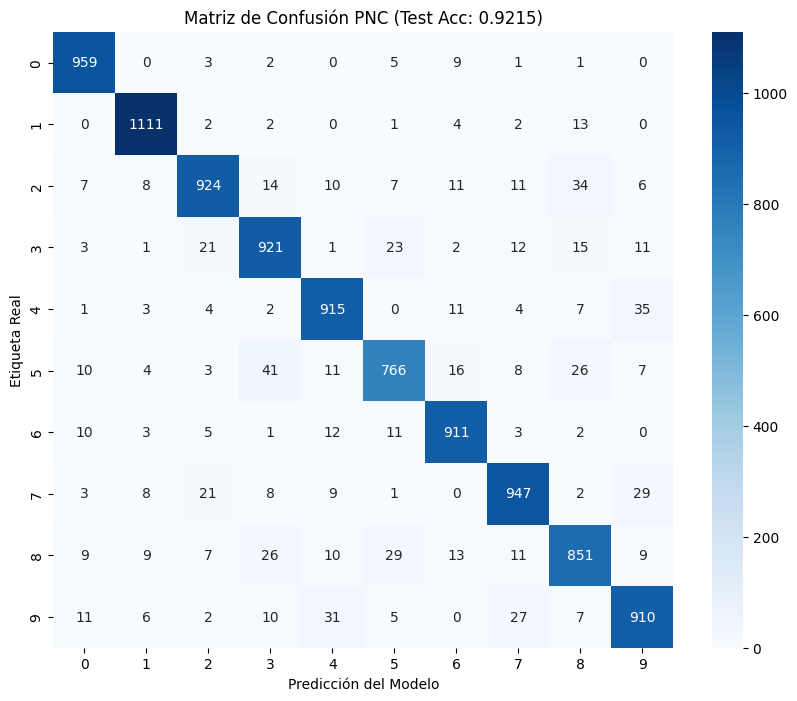

[✅] Matriz de confusión y métricas guardadas exitosamente.


In [14]:

# ==========================================
# 7. EVALUACIÓN FINAL EN TEST SET (10,000 imgs)
# ==========================================
print("\n--- EVALUACIÓN FINAL EN CONJUNTO DE TEST ---")
modelo_final.eval()
test_loss, test_correct, test_total = 0.0, 0, 0

all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data = data.squeeze(1).to(device)
        data = (data * 255.0).long().float()
        target = target.to(device)

        log_probs = modelo_final(data)
        loss = criterion(log_probs, target)

        test_loss += loss.item() * data.size(0)
        _, predicted = log_probs.max(1)
        test_total += target.size(0)
        test_correct += predicted.eq(target).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

test_acc_final = test_correct / test_total
print(f"[🏆] ACCURACY FINAL EN TEST (PNC): {test_acc_final:.4f} ({(test_acc_final*100):.2f}%)")

# 8. Matriz de Confusión y Reporte
cm = confusion_matrix(all_targets, all_preds)
reporte = classification_report(all_targets, all_preds, output_dict=True)
df_reporte = pd.DataFrame(reporte).transpose()
df_reporte.to_csv(ruta_reporte_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusión PNC (Test Acc: {test_acc_final:.4f})')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.savefig(ruta_matriz_conf)
plt.show()

print(f"[✅] Matriz de confusión y métricas guardadas exitosamente.")


--- GENERANDO GRÁFICAS DE ENTRENAMIENTO ---


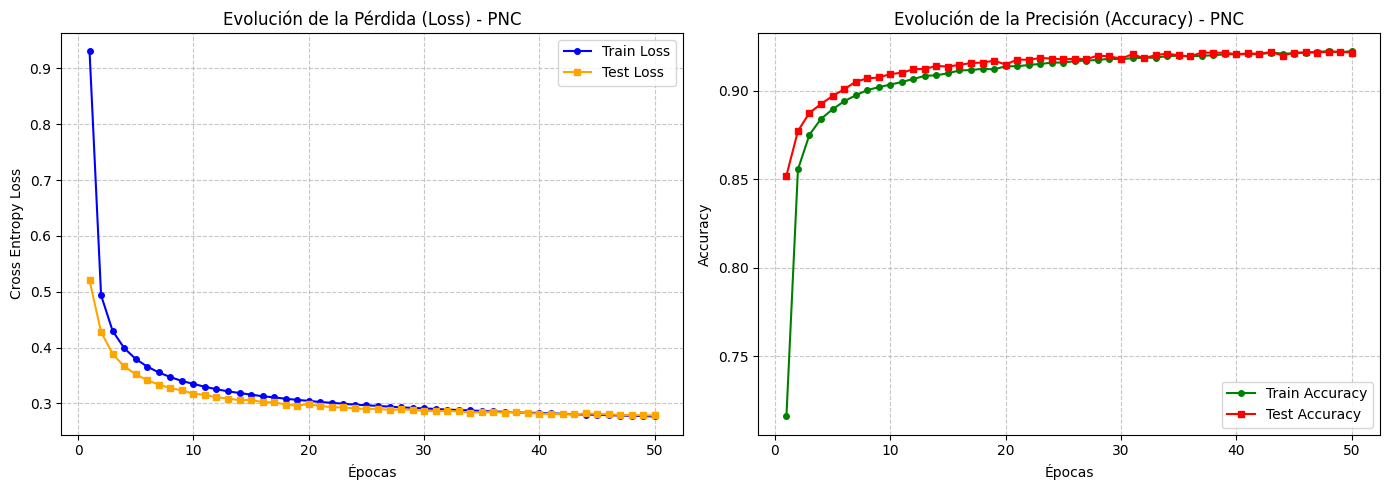

[✅] Gráficas de entrenamiento guardadas en: /content/Analisis-KDM-PNC/resultados/mnist/metricas/pnc_training_curves.png

--- GENERANDO MATRIZ DE CONFUSIÓN FINAL ---
[🏆] ACCURACY FINAL EN TEST (PNC): 0.9215


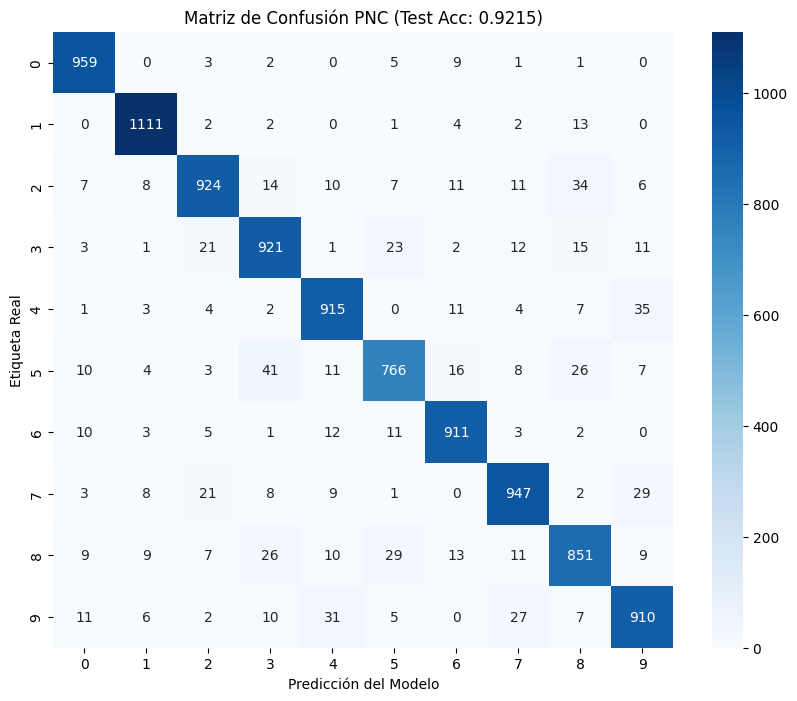

[✅] Matriz de confusión guardada en: /content/Analisis-KDM-PNC/resultados/mnist/metricas/pnc_confusion_matrix.png


In [18]:
import os

# ==========================================
# 7. GRÁFICAS DE EVOLUCIÓN (ACCURACY Y LOSS)
# ==========================================
print("\n--- GENERANDO GRÁFICAS DE ENTRENAMIENTO ---")

# SEGURIDAD MLOps: Asegurar que el directorio de métricas existe
os.makedirs(os.path.dirname(ruta_curvas_entrenamiento), exist_ok=True)

# Crear la figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Loss
ax1.plot(range(1, EPOCHS_FINAL + 1), historial_train_loss, label='Train Loss', color='blue', marker='o', markersize=4)
ax1.plot(range(1, EPOCHS_FINAL + 1), historial_test_loss, label='Test Loss', color='orange', marker='s', markersize=4)
ax1.set_title('Evolución de la Pérdida (Loss) - PNC')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Cross Entropy Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfica de Accuracy
ax2.plot(range(1, EPOCHS_FINAL + 1), historial_train_acc, label='Train Accuracy', color='green', marker='o', markersize=4)
ax2.plot(range(1, EPOCHS_FINAL + 1), historial_test_acc, label='Test Accuracy', color='red', marker='s', markersize=4)
ax2.set_title('Evolución de la Precisión (Accuracy) - PNC')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

# CRÍTICO: Guardar ANTES de mostrar
plt.savefig(ruta_curvas_entrenamiento, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig) # Liberar memoria

print(f"[✅] Gráficas de entrenamiento guardadas en: {ruta_curvas_entrenamiento}")

# ==========================================
# 8. MATRIZ DE CONFUSIÓN Y REPORTE FINAL
# ==========================================
print("\n--- GENERANDO MATRIZ DE CONFUSIÓN FINAL ---")

# Re-asegurar directorio
os.makedirs(os.path.dirname(ruta_matriz_conf), exist_ok=True)

all_preds = []
all_targets = []
modelo_final.eval()

with torch.no_grad():
    for data, target in test_loader:
        data = data.squeeze(1).to(device)
        data = (data * 255.0).long().float()
        target = target.to(device)
        log_probs = modelo_final(data)
        _, predicted = log_probs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

test_acc_final = historial_test_acc[-1]
print(f"[🏆] ACCURACY FINAL EN TEST (PNC): {test_acc_final:.4f}")

cm = confusion_matrix(all_targets, all_preds)
reporte = classification_report(all_targets, all_preds, output_dict=True)
pd.DataFrame(reporte).transpose().to_csv(ruta_reporte_test)

# Graficar Matriz
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusión PNC (Test Acc: {test_acc_final:.4f})')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')

# CRÍTICO: Guardar ANTES de mostrar
plt.savefig(ruta_matriz_conf, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"[✅] Matriz de confusión guardada en: {ruta_matriz_conf}")

In [19]:
# ==========================================
# BLOQUE 4: MLOps - GUARDAR EN GITHUB
# ==========================================
import os

print("\n--- INICIANDO BACKUP A GITHUB ---")
%cd {REPO_PATH}

# 1. Configurar identidad de Git (Colab)
# (Puedes dejar estos por defecto, es solo para que Git acepte el commit)
!git config --global user.email "bspd1007@gmail.com"
!git config --global user.name "bspd1007 (Google Colab)"

# 2. Mostrar qué archivos han cambiado o son nuevos
print("\n[INFO] Archivos modificados/creados:")
!git status -s

# 3. Agregar todos los cambios (Modelos, CSVs, Gráficas, Notebook)
!git add .

# 4. Hacer el Commit
MENSAJE_COMMIT = "feat(PNC): Entrenamiento completo de PNC, matriz de confusión y métricas guardadas"
!git commit -m "{MENSAJE_COMMIT}"

# 5. Hacer el Push a la rama principal (main)
print("\n[INFO] Subiendo archivos al repositorio...")
!git push origin main

print("\n[✅] ¡Todo guardado exitosamente en GitHub!")
%cd /content


--- INICIANDO BACKUP A GITHUB ---
/content/Analisis-KDM-PNC

[INFO] Archivos modificados/creados:
 M resultados/mnist/metricas/pnc_confusion_matrix.png
 M resultados/mnist/metricas/pnc_training_curves.png
[main 9bea484] feat(PNC): Entrenamiento completo de PNC, matriz de confusión y métricas guardadas
 2 files changed, 0 insertions(+), 0 deletions(-)
 rewrite resultados/mnist/metricas/pnc_confusion_matrix.png (96%)
 rewrite resultados/mnist/metricas/pnc_training_curves.png (95%)

[INFO] Subiendo archivos al repositorio...
Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 352.02 KiB | 10.35 MiB/s, done.
Total 7 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Steven10P/Analisis-KDM-PNC.git
   457887d..9bea484  main -> main

[✅] ¡Todo guardado exitosamente en GitHub!
/content